In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Annotated
from langchain_ollama import ChatOllama
from pydantic import BaseModel, Field
import operator

In [2]:
generate_llm = ChatOllama(model="qwen2.5:1.5b", temperature=2)
evaluate_llm = ChatOllama(model="qwen2.5:1.5b", temperature=0)
optimize_llm = ChatOllama(model="qwen2.5:1.5b", temperature=1)


In [3]:
class QAstate(TypedDict):
    message: str
    article: str
    feedback: str
    score: int
    iteration: int
    max_iteration: int
    history:Annotated[list[str], operator.add]

In [4]:
class messageSchema(BaseModel):
    feedback:str = Field(description="Provide short feedback on the article")
    score: int = Field(description="Provide a score out of 10 based on the quality of the article", ge=1, le=10)

In [5]:
def generate(state):
    topic=state['message']
    prompt= f"Gnerate a short article on following topic: {topic} under 200 words"
    response= generate_llm.invoke(prompt).content
    return {'article': response}

In [6]:
def evaluate(state):
    prompt= f"Evaluate the following article on topic: {state['message']} and body: {state['article']} and give a very short feedback mentionning the strengths and weaknesses"
    structured_evaluate_llm= evaluate_llm.with_structured_output(messageSchema)
    response= structured_evaluate_llm.invoke(prompt)
    
    return {'feedback': response.feedback, 'score': response.score, 'history':[response]}

In [7]:
def optimizer(state):
    
    prompt=f"""
Improve the article based on this feedback:
"{state['feedback']}"

Topic: "{state['message']}"
Original Article:
{state['article']}

Re-write it as a short, well structured, grammatically rich. Avoid Q&A style and stay under 200 words.
"""

    response= optimize_llm.invoke(prompt).content
    iteration=state['iteration']+1
    
    return {'article':response, 'iteration': iteration}

In [8]:
def approved(state):
    return state

In [9]:
def conditional_node(state)-> Literal['approved', 'optimizer']:
    if state['score']>7 or state['iteration']>= state['max_iteration']:
        return "approved"
    else:
        return "optimizer"

In [10]:
graph=StateGraph(QAstate)
graph.add_node('generate', generate)
graph.add_node('evaluate', evaluate)
graph.add_node('optimizer', optimizer)
graph.add_node('approved', approved)

graph.add_edge(START, 'generate')
graph.add_edge('generate', 'evaluate')
graph.add_conditional_edges('evaluate', conditional_node)
graph.add_edge('optimizer', 'evaluate')
graph.add_edge('approved', END)

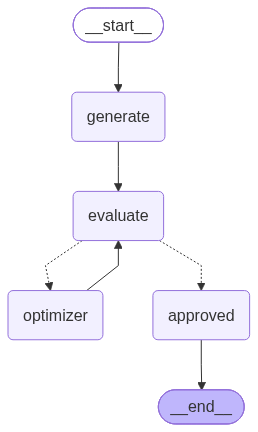

In [11]:
workflow= graph.compile()
workflow

In [12]:
initial_state={
    'message':"Literature in Bangladesh",
    "iteration": 1,
    "max_iteration": 5
    }
final_state= workflow.invoke(initial_state)

In [13]:
final_state

{'message': 'Literature in Bangladesh',
 'article': "Literature in Bangladesh plays a significant role in the cultural heritage and historical narrative of the country. It includes traditional folk literature, classical literature, modern literature, and literature in the form of short stories, poetry, and drama. The literary tradition has a rich history dating back to ancient times, influenced by various factors such as religion, language, and geography.\nBangladesh has a rich cultural tradition and has a strong tradition of literature. Literature has played an essential role in the nation's identity and has influenced its development over the centuries. The nation's literature has been divided into three categories: classical literature, which includes books of religious texts and poems of poets, modern literature, which includes novels, short stories, plays, and other forms of literature, and popular literature, which includes novels and short stories.\nThe language of Bangladesh is